# Engenharia de Features para Predição de Preços

Foram criadas três novas features a partir das características originais dos diamantes:

* **`xyz`** — aproximação do volume a partir das dimensões `x`, `y` e `z`;
* **`carat_sq`** — termo quadrático do peso em quilates;
* **`(xyz)^2`** — termo não linear baseado no volume estimado.

Após a análise exploratória e o tratamento de valores inconsistentes, as variáveis categóricas foram codificadas com **Ordinal Encoding**. Features numéricas assimétricas e o alvo `price` receberam transformação `log1p`, enquanto os preditores foram padronizados com **StandardScaler**.

Dois modelos de **Regressão Linear** são comparados:

1. utilizando apenas as features originais;
2. utilizando também as novas features.

O impacto da engenharia de features é avaliado no conjunto de teste por **MAE, RMSE e R²**, permitindo verificar empiricamente se as novas representações agregam informação preditiva.


## Carregando Dados

In [1]:
import pandas as pd

diamonds = pd.read_csv('../data/diamonds.csv')
print(diamonds.shape)
diamonds.head()

(53940, 11)


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## EDA

In [2]:
diamonds.describe().round(1)

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0,53940.0
mean,26970.5,0.8,61.7,57.5,3932.8,5.7,5.7,3.5
std,15571.3,0.5,1.4,2.2,3989.4,1.1,1.1,0.7
min,1.0,0.2,43.0,43.0,326.0,0.0,0.0,0.0
25%,13485.8,0.4,61.0,56.0,950.0,4.7,4.7,2.9
50%,26970.5,0.7,61.8,57.0,2401.0,5.7,5.7,3.5
75%,40455.2,1.0,62.5,59.0,5324.2,6.5,6.5,4.0
max,53940.0,5.0,79.0,95.0,18823.0,10.7,58.9,31.8


In [3]:
diamonds[diamonds['carat'] == 0]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z


### Encontrando outliers positivos e negativos

In [4]:
cols = ["x", "y", "z", "carat"]

for col in cols:
    print(f"\n{col.upper()} - 3 menores valores")
    display(
        diamonds
        .sort_values(col)
        .head(3)
        [["carat", "cut", "color", "clarity", "price", "x", "y", "z", "depth", "table"]]
    )

    print(f"\n{col.upper()} - 3 maiores valores")
    display(
        diamonds
        .sort_values(col, ascending=False)
        .head(3)
        [["carat", "cut", "color", "clarity", "price", "x", "y", "z", "depth", "table"]]
    )


X - 3 menores valores


,carat,cut,color,clarity,price,x,y,z,depth,table
24520,1.56,Ideal,G,VS2,12800,0.0,0.00,0.0,62.2,54.0
11182,1.07,Ideal,F,SI2,4954,0.0,6.62,0.0,61.6,56.0
49556,0.71,Good,F,SI2,2130,0.0,0.00,0.0,64.1,60.0



X - 3 maiores valores


,carat,cut,color,clarity,price,x,y,z,depth,table
27415,5.01,Fair,J,I1,18018,10.74,10.54,6.98,65.5,59.0
27630,4.50,Fair,J,I1,18531,10.23,10.16,6.72,65.8,58.0
25998,4.01,Premium,I,I1,15223,10.14,10.10,6.17,61.0,61.0



Y - 3 menores valores


...

,carat,cut,color,clarity,price,x,y,z,depth,table
48410,0.51,Very Good,E,VS1,1970,5.12,5.15,31.80,61.8,54.7
24067,2.00,Premium,H,SI2,12210,8.09,58.90,8.06,58.9,57.0
27415,5.01,Fair,J,I1,18018,10.74,10.54,6.98,65.5,59.0



CARAT - 3 menores valores


,carat,cut,color,clarity,price,x,y,z,depth,table
14,0.2,Premium,E,SI2,345,3.79,3.75,2.27,60.2,62.0
31597,0.2,Ideal,D,VS2,367,3.81,3.77,2.33,61.5,57.0
31596,0.2,Premium,F,VS2,367,3.73,3.71,2.33,62.6,59.0



CARAT - 3 maiores valores


,carat,cut,color,clarity,price,x,y,z,depth,table
27415,5.01,Fair,J,I1,18018,10.74,10.54,6.98,65.5,59.0
27630,4.50,Fair,J,I1,18531,10.23,10.16,6.72,65.8,58.0
27130,4.13,Fair,H,I1,17329,10.00,9.85,6.43,64.8,61.0


## Feature Engineer

**Removendo 0´s e valores absurdos de x, y e z**

In [5]:
indices_absurdos = [24067, 49189, 48410]
print('Valores absurdos encontrados em y e z:')
display(diamonds.loc[indices_absurdos])

Valores absurdos encontrados em y e z:


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
24067,24068,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.90,8.06
49189,49190,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.80,5.12
48410,48411,0.51,Very Good,E,VS1,61.8,54.7,1970,5.12,5.15,31.80


In [6]:
display(diamonds[diamonds['x'] == 0].head())
print(f'Antes da limpeza: {diamonds.shape}')
diamonds.drop(indices_absurdos, inplace=True)  # remover registros com x=0 (provável erro de medição)
diamonds.drop(diamonds[diamonds['x'] == 0].index, inplace=True)  # remover registros com x=0 (provável erro de medição)
diamonds.drop(diamonds[diamonds['y'] == 0].index, inplace=True)  # remover registros com y=0 (provável erro de medição)
diamonds.drop(diamonds[diamonds['z'] == 0].index, inplace=True)  # remover registros com z=0 (provável erro de medição)

print(f"Após limpeza: {diamonds.shape}")

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
11182,11183,1.07,Ideal,F,SI2,61.6,56.0,4954,0.0,6.62,0.0
11963,11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.0,0.00,0.0
15951,15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.0,0.00,0.0
24520,24521,1.56,Ideal,G,VS2,62.2,54.0,12800,0.0,0.00,0.0
26243,26244,1.20,Premium,D,VVS1,62.1,59.0,15686,0.0,0.00,0.0


Antes da limpeza: (53940, 11)
Após limpeza: (53917, 11)


**Novas Features**

**x*y*z (Volume)**: aproxima o tamanho físico total do diamante de uma maneira nova.

**(x*y*z)^2**: captura crescimento não linear com o novo volume

**carat^2**: captura crescimento não linear do preço com o peso.



In [7]:
diamonds['carat_sq'] = diamonds['carat'] ** 2
diamonds['xyz'] = diamonds['x'] * diamonds['y'] * diamonds['z']  # volume aproximado do diamante
diamonds['(xyz)^2'] = diamonds['xyz'] ** 2

diamonds.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z,carat_sq,xyz,(xyz)^2
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,0.0529,38.202030,1459.395096
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,0.0441,34.505856,1190.654098
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,0.0529,38.076885,1449.849171
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,0.0841,46.724580,2183.186376
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,0.0961,51.917250,2695.400848


**Análise exploratória das features criadas**

Abaixo, comparo as novas features com `price` para verificar se elas carregam sinal preditivo. Também comparo com `carat`, porque features muito correlacionadas com `carat` podem ajudar a Regressão Linear, mas também podem estar trazendo informação parcialmente redundante.

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

created_features = ['xyz', 'carat_sq', '(xyz)^2']

feature_analysis = pd.DataFrame({
    'pearson_com_price': diamonds[created_features + ['price']]
        .corr(numeric_only=True)['price']
        .drop('price'),

    'spearman_com_price': [
        spearmanr(diamonds[col], diamonds['price']).correlation
        for col in created_features
    ],

    'pearson_com_carat': diamonds[created_features + ['carat']]
        .corr(numeric_only=True)['carat']
        .drop('carat'),

    'spearman_com_carat': [
        spearmanr(diamonds[col], diamonds['carat']).correlation
        for col in created_features
    ]
}, index=created_features)

feature_analysis.round(4)

,pearson_com_price,spearman_com_price,pearson_com_carat,spearman_com_carat
xyz,0.9235,0.9639,0.9989,0.9985
carat_sq,0.8909,0.9629,0.9535,1.0000
(xyz)^2,0.8956,0.9639,0.9540,0.9985


#### Análise das novas features

As features `xyz` e `carat_sq` apresentaram forte relação positiva com o preço do diamante. Nos gráficos de dispersão e nas correlações calculadas, observa-se que ambas carregam sinal preditivo relevante relacionado ao tamanho físico e ao valor do diamante.

A feature `xyz`, utilizada como aproximaçãoo do volume do diamante, reforça a importância do tamanho físico no preço?.

A variável `carat_sq` evidencia uma relação não linear entre quilate e preço, mostrando que o valor do diamante cresce de maneira acelerada para pedras maiores.

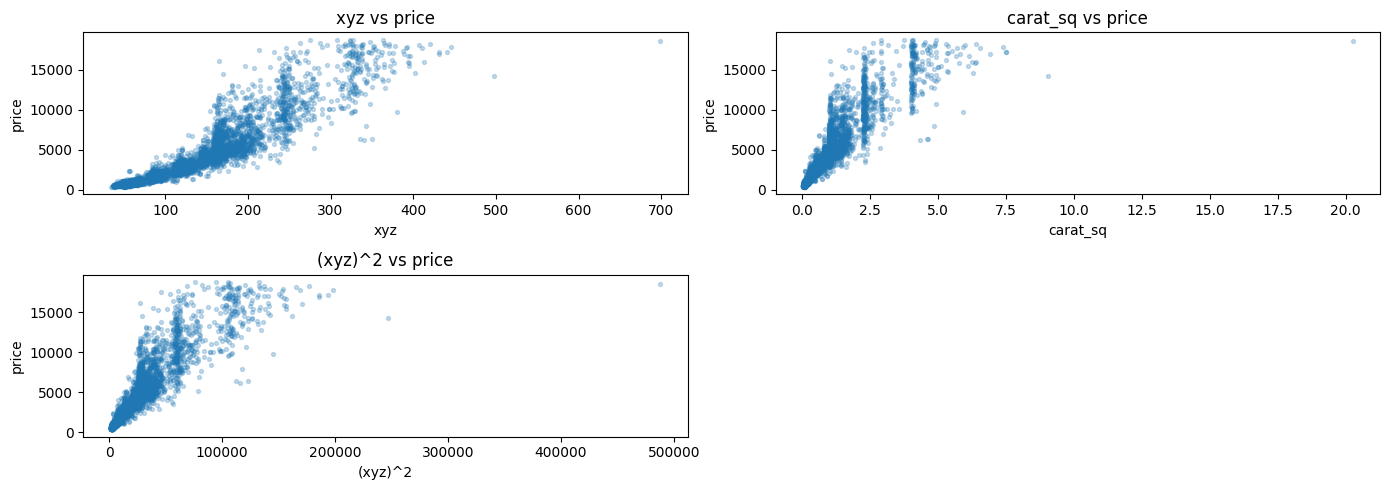

In [9]:
import matplotlib.pyplot as plt
sample = diamonds.sample(n=min(5000, len(diamonds)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 5))
axes = axes.ravel()

for ax, col in zip(axes, created_features):
    ax.scatter(sample[col], sample['price'], alpha=0.25, s=8)
    ax.set_title(f'{col} vs price')
    ax.set_xlabel(col)
    ax.set_ylabel('price')

axes[-1].axis('off')  # não plota nada no último subplot

plt.tight_layout()
plt.show()

**Heatmaps de correlação das features criadas**

Abaixo, uso mapas de cores para visualizar a correlação das novas features com `price` e com as demais vari?veis numéricas.

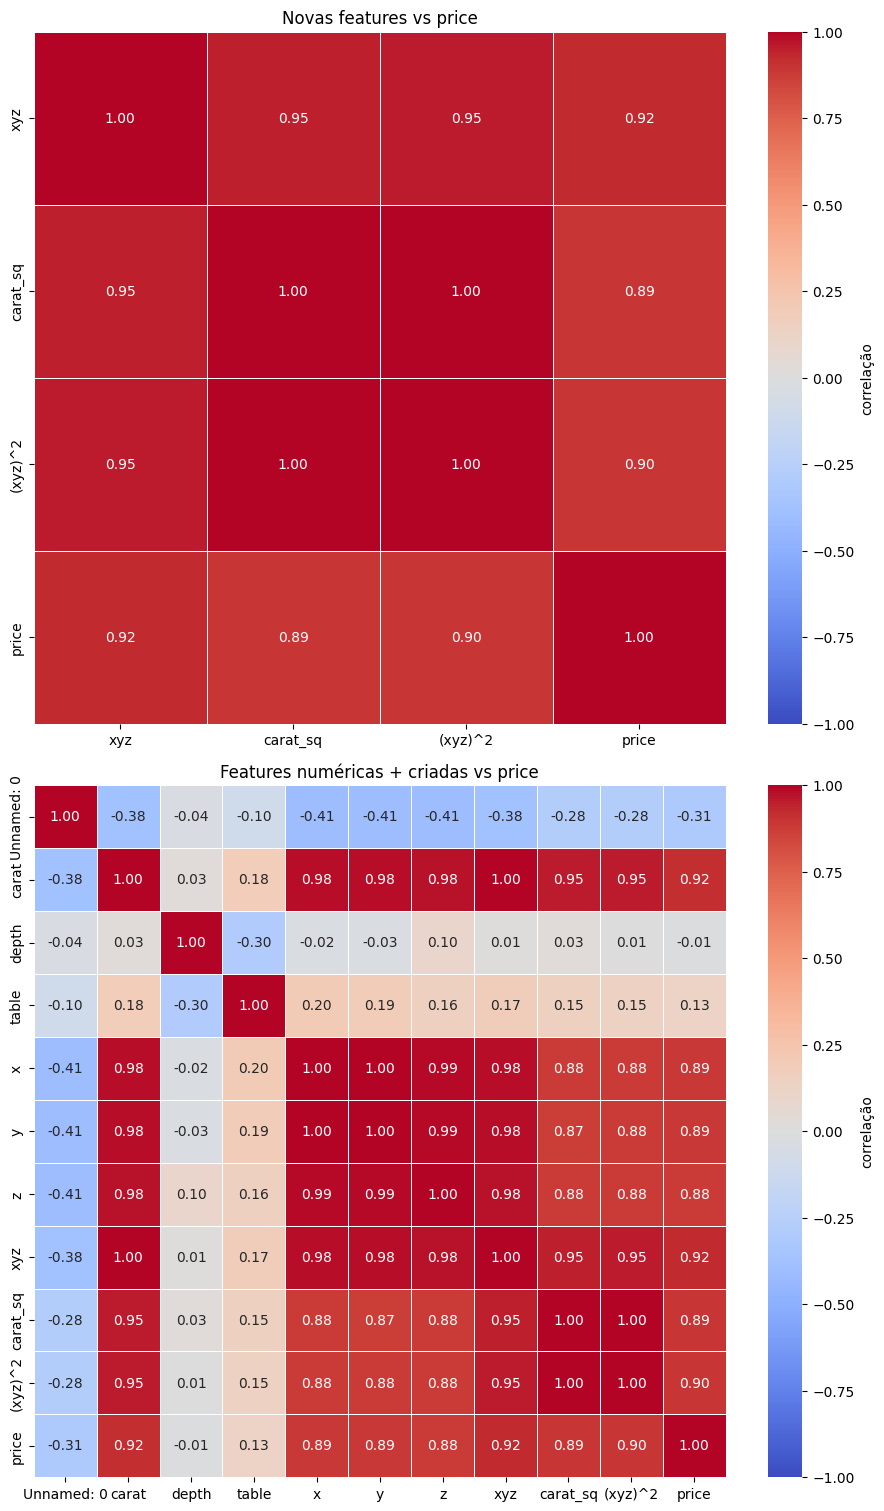

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_original_features = [
    col for col in diamonds.select_dtypes(include="number").columns
    if col not in created_features + ["price"]
]

heatmap_1_cols = created_features + ["price"]
heatmap_2_cols = numeric_original_features + created_features + ["price"]

corr_heatmaps = [
    (diamonds[heatmap_1_cols].corr(), "Novas features vs price"),
    (diamonds[heatmap_2_cols].corr(), "Features numéricas + criadas vs price"),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 15), constrained_layout=True)

for ax, (corr, title) in zip(axes, corr_heatmaps):
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "correlação"}
    )
    ax.set_title(title)

plt.show()

##  EDA (again)

In [11]:
diamonds.describe().round(1)

,Unnamed: 0,carat,depth,table,price,x,y,z,carat_sq,xyz,(xyz)^2
count,53917.0,53917.0,53917.0,53917.0,53917.0,53917.0,53917.0,53917.0,53917.0,53917.0,53917.0
mean,26971.6,0.8,61.7,57.5,3930.9,5.7,5.7,3.5,0.9,129.8,22693.2
std,15571.1,0.5,1.4,2.2,3987.2,1.1,1.1,0.7,1.1,76.5,27589.5
min,1.0,0.2,43.0,43.0,326.0,3.7,3.7,1.1,0.0,31.7,1005.4
25%,13487.0,0.4,61.0,56.0,949.0,4.7,4.7,2.9,0.2,65.2,4249.5
50%,26973.0,0.7,61.8,57.0,2401.0,5.7,5.7,3.5,0.5,114.8,13188.3
75%,40456.0,1.0,62.5,59.0,5323.0,6.5,6.5,4.0,1.1,170.8,29187.9
max,53940.0,5.0,79.0,95.0,18823.0,10.7,10.5,7.0,25.1,790.1,624310.5


Analisando distribuições de todas as features pra investigar necessidades de correção de escala e assimetria

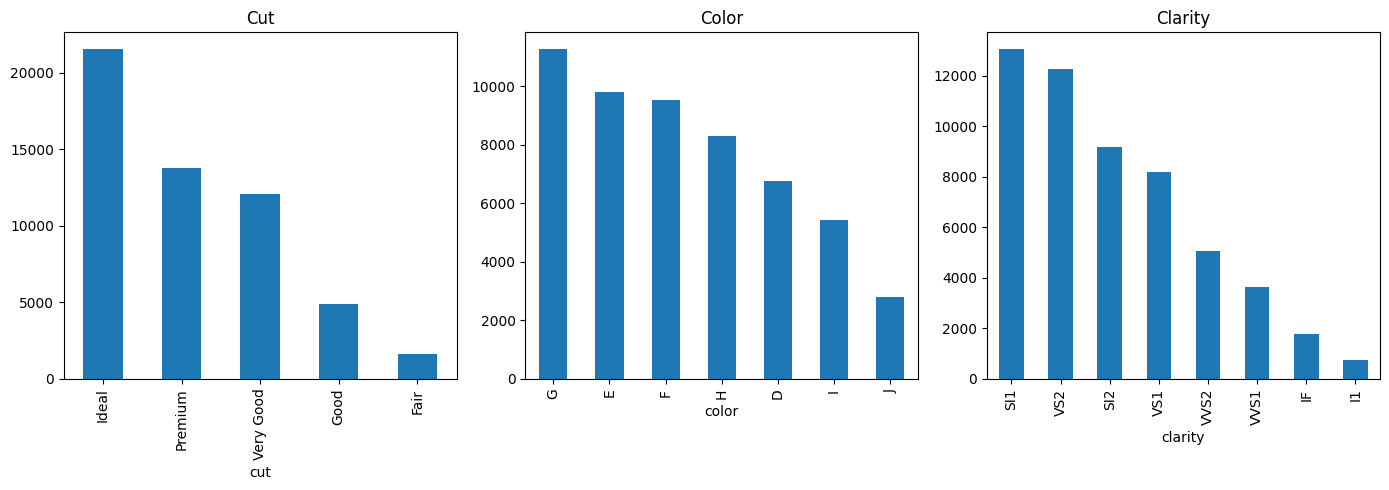

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

diamonds['cut'].value_counts().plot(kind='bar', ax=axes[0], title='Cut')
diamonds['color'].value_counts().plot(kind='bar', ax=axes[1], title='Color')
diamonds['clarity'].value_counts().plot(kind='bar', ax=axes[2], title='Clarity')

plt.tight_layout()
plt.show()

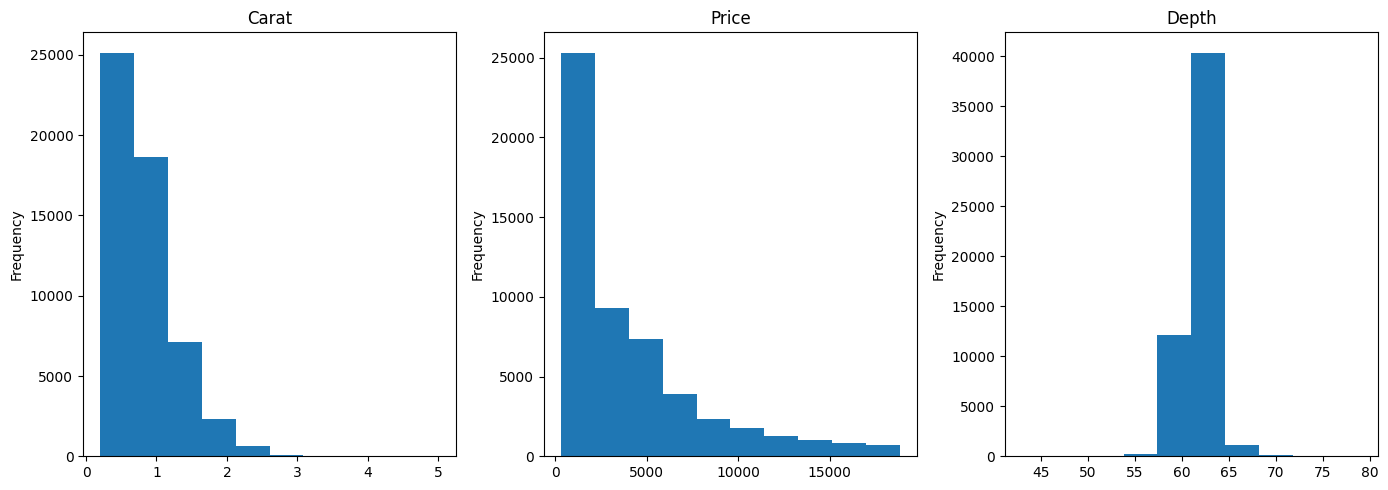

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(14, 5)) # criar uma grade 1x3 para os gráficos

diamonds['carat'].plot(kind='hist', ax=axes[0], title='Carat')
diamonds['price'].plot(kind='hist', ax=axes[1], title='Price')
diamonds['depth'].plot(kind='hist', ax=axes[2], title='Depth')


plt.tight_layout()
plt.show()

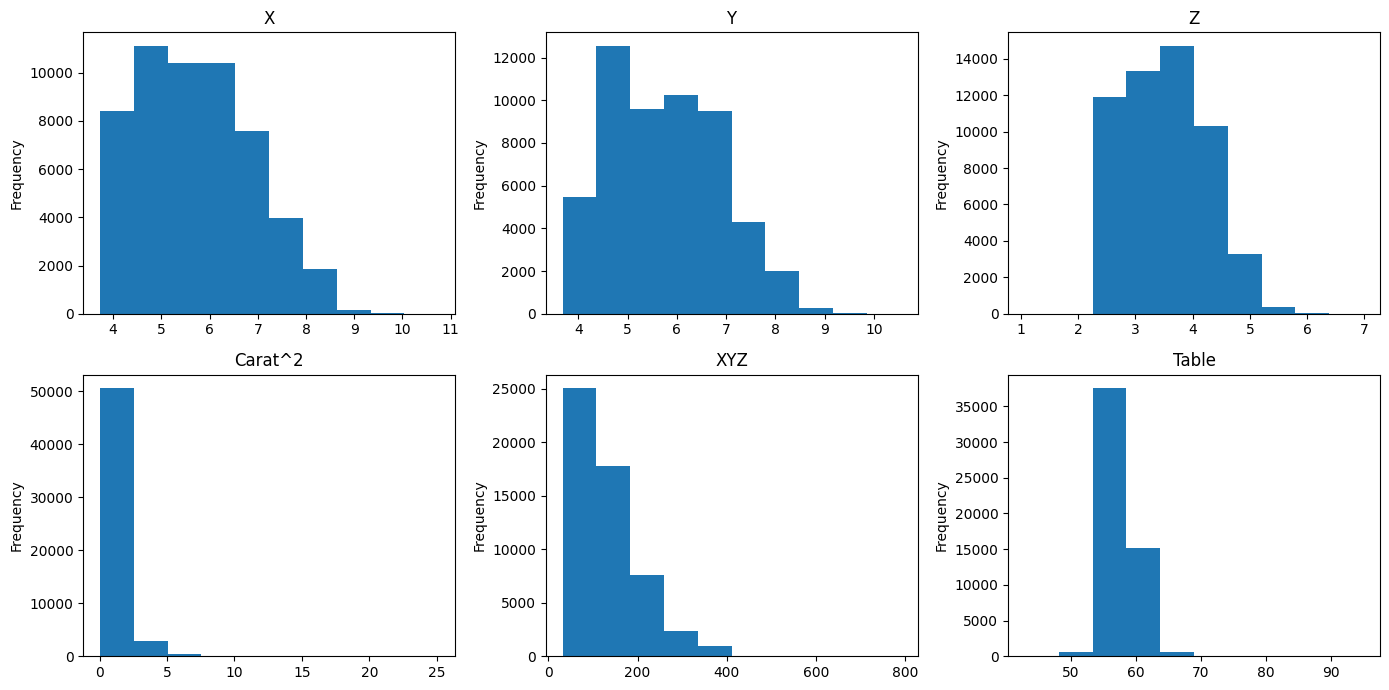

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

hist_cols = ['x', 'y', 'z', 'carat_sq', 'xyz', 'table']
hist_titles = ['X', 'Y', 'Z', 'Carat^2', 'XYZ', 'Table']

for ax, col, title in zip(axes, hist_cols, hist_titles):
    diamonds[col].plot(kind='hist', ax=ax, title=title)

plt.tight_layout()
plt.show()

## Pré Processamento

As variáveis categóricas `cut`, `color` e `clarity` foram transformadas com `OrdinalEncoder`, pois possuem ordem sem?ntica relacionada a qualidade do diamante.  

As variáveis numéricas `x`, `z`, `xyz`, `carat_sq` e `carat` receberam transforma??o `log1p` devido a forte assimetria a direita observada em suas distribuições, reduzindo o impacto de valores extremos. O alvo `price` tamb?m foi transformado com `log1p` pelo mesmo motivo.  

Por fim, todas as features foram padronizadas com `StandardScaler`, garantindo m?dia zero e variância unitária, o que favorece o treinamento da Regressão Linear.

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

class DiamondsDataset:
    def __init__(self, dataframe: pd.DataFrame, target_column: str):
        self.df = dataframe.copy()          # Evita modificar o DataFrame original fora da classe
        self.target_column = target_column
        self.encoder = None
        self.scaler = None

        self.categorical_cols = ['cut', 'color', 'clarity']
        self.category_orders = [                                # ordem de categorias para encoding ordinal
            ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],  # cut
            ['J', 'I', 'H', 'G', 'F', 'E', 'D'],                # color
            ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # clarity
        ]
        self.log1p_cols = ['x', 'carat', 'carat_sq', 'xyz', 'z', ] # features numéricas com assimetria significativa que serão transformadas com log1p

    def split_train_test_val(self, test_size=0.2, val_size=0.0, random_state=42): # posso sobrescrever esses parâmetros
        X = self.df.drop(columns=[self.target_column]) # features
        y = np.log1p(self.df[self.target_column]) # log do preço do diamante

        # Primeiro, divide em treino e teste mas essa função não retorna nada ainda
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state)

        if val_size > 0: # train_test_split não aceita proporção de validação, então criamos
            val_relative = val_size / (1 - test_size)
            self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
                X_temp, y_temp, test_size=val_relative, random_state=random_state)
        else:
            self.X_train, self.X_val, self.y_train, self.y_val = X_temp, None, y_temp, None
    
    # Aplica encoding ordinal às colunas categóricas usando a ordem definida em category_orders
    def encode_categorical(self): 
        self.encoder = OrdinalEncoder(categories=self.category_orders)

        self.X_train[self.categorical_cols] = self.encoder.fit_transform(self.X_train[self.categorical_cols])

        if self.X_val is not None:
            self.X_val[self.categorical_cols] = self.encoder.transform(self.X_val[self.categorical_cols])

        self.X_test[self.categorical_cols] = self.encoder.transform(self.X_test[self.categorical_cols])

    # A função apply_log1p foi mantida, mas agora é aplicada apenas às colunas definidas em log1p_cols, que são as que apresentam assimetria significativa. As outras colunas numéricas serão padronizadas normalmente pela função scale_features.
    def apply_log1p(self): # Corrige assimetria nas features definidas, se elas existirem no dataset
        log_cols = [col for col in self.log1p_cols if col in self.X_train.columns]

        self.X_train[log_cols] = np.log1p(self.X_train[log_cols])

        if self.X_val is not None:
            self.X_val[log_cols] = np.log1p(self.X_val[log_cols])

        self.X_test[log_cols] = np.log1p(self.X_test[log_cols])

    # Padroniza todas as features após o tratamento categórico
    def scale_features(self): 
        feature_cols = self.X_train.columns
        self.scaler = StandardScaler()

        self.X_train[feature_cols] = self.scaler.fit_transform(self.X_train[feature_cols])

        if self.X_val is not None:
            self.X_val[feature_cols] = self.scaler.transform(self.X_val[feature_cols])

        self.X_test[feature_cols] = self.scaler.transform(self.X_test[feature_cols])

    def scale_numeric(self): # Mantido por compatibilidade; agora padroniza todas as features
        self.scale_features()

    def preprocess(self):
        self.encode_categorical()
        self.apply_log1p()
        self.scale_features()

    def get_train_val_test(self):
        return self.X_train, self.X_val, self.X_test, self.y_train, self.y_val, self.y_test

    def get_encoder(self):
        return self.encoder

    def get_scaler(self):
        return self.scaler

    def inverse_transform_target(self, y_log):
        return np.expm1(y_log)


Aplicando aos dados

In [16]:
dataset = DiamondsDataset(diamonds, target_column='price')
dataset.split_train_test_val(test_size=0.2, val_size=0.1, random_state=42)
dataset.preprocess()

X_train, X_val, X_test, y_train, y_val, y_test = dataset.get_train_val_test()

print(f'Dataset de treino apos pre-processamento: {X_train.shape}')
print(f'Dataset de validação apos pre-processamento: {X_val.shape}')
print(f'Dataset de teste apos pre-processamento: {X_test.shape}''\n')

print(f'Primeiras linhas do dataset de teste: \n{X_test.head()}')


Dataset de treino apos pre-processamento: (37741, 13)
Dataset de validação apos pre-processamento: (5392, 13)
Dataset de teste apos pre-processamento: (10784, 13)

Primeiras linhas do dataset de teste: 
       Unnamed: 0     carat       cut     color   clarity     depth     table  \
33878    0.441988 -1.198134  0.984046  0.937873 -0.031237  0.247653 -1.100512   
21091   -0.379433  0.989006 -0.809627 -0.235763  0.577081 -0.382870  0.244558   
36461    0.607917 -1.166816  0.087210  1.524691 -0.031237 -0.032580  0.692915   
40257    0.851767 -0.895253  0.984046 -0.822581  1.185400 -0.663103 -1.100512   
1632    -1.629455 -0.101734  0.984046  0.937873  0.577081  0.668002 -0.203799   

              x         y         z  carat_sq       xyz   (xyz)^2  
33878 -1.338482 -1.291856 -1.318929 -0.994176 -1.364646 -0.733247  
21091  1.015682  1.048367  0.989225  0.926290  1.024228  0.612113  
36461 -1.327084 -1.282855 -1.336994 -0.981192 -1.363120 -0.733085  
40257 -0.803703 -0.850814 -0.899486 -0

## Treino e Resultado dos Modelos

Vamos treinar dois modelos de Regressão Linear, um com as features originais do dataset e outro com minhas novas features acrescentadas. A intenção é investigar se as novas features farão efeito no modelo

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

created_features = ['xyz', 'carat_sq', '(xyz)^2'] # lista das features criadas
original_features = [col for col in X_train.columns if col not in created_features] # lista das features originais 
original_plus_created_features = original_features + created_features # lista de todas as features usadas no segundo modelo (originais + criadas)

modelo_original = LinearRegression() # modelo apenas com features originais
modelo_original.fit(X_train[original_features], y_train)
y_pred_original_log = modelo_original.predict(X_test[original_features])

modelo_com_features = LinearRegression() # modelo com features originais + criadas
modelo_com_features.fit(X_train[original_plus_created_features], y_train)
y_pred_com_features_log = modelo_com_features.predict(X_test[original_plus_created_features])

y_test_price = dataset.inverse_transform_target(y_test)
y_pred_original_price = dataset.inverse_transform_target(y_pred_original_log)
y_pred_com_features_price = dataset.inverse_transform_target(y_pred_com_features_log)

results = pd.DataFrame({
    'modelo': ['LinearRegression - features originais', 'LinearRegression - originais + criadas'],
    'qtd_features': [len(original_features), len(original_plus_created_features)],
    'MAE_preco': [
        mean_absolute_error(y_test_price, y_pred_original_price),
        mean_absolute_error(y_test_price, y_pred_com_features_price)
    ],
    'RMSE_preco': [
        mean_squared_error(y_test_price, y_pred_original_price) ** 0.5,
        mean_squared_error(y_test_price, y_pred_com_features_price) ** 0.5
    ],
    'R2_preco': [
        r2_score(y_test_price, y_pred_original_price),
        r2_score(y_test_price, y_pred_com_features_price)
    ]
})

results.round(3)

,modelo,qtd_features,MAE_preco,RMSE_preco,R2_preco
0,LinearRegression - features originais,10,473.261,969.471,0.94
1,LinearRegression - originais + criadas,13,423.346,792.880,0.96


O modelo com features criadas apresentou desempenho ligeiramente superior ao modelo com apenas features originais. O MAE caiu de aproximadamente 476.46 para 444.50, indicando menor erro médio absoluto em dólares. O RMSE também reduziu, de 984.07 para 963.55, mostrando que os erros maiores também foram um pouco menores. Além disso, o R² aumentou de 0.939 para 0.941, sugerindo que o modelo com features criadas explica uma parcela ligeiramente maior da variação dos preços.

Portanto, as novas features parecem agregar valor preditivo ao modelo, embora a melhora seja relativamente pequena. Isso não significa que adicionar features novas usando as features originais é sempre uma técnica efetiva. Essa tarefa exige uma atenção especial em problemas como:  Multicolinearidade entre features, Overfitting e Alta dimensionalidade